<a href="https://colab.research.google.com/github/Tomzy-sketch/techcrush-practice/blob/main/PREDICT_DIABETICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can replace `requests` with the name of any other library you wish to install.

In [ ]:
sensor_id = "ESP32"
temperature = 31.3
pump_active = True
fish_count = input("How many fish are the pond: ")

print(f"Sensor {sensor_id} reports a temperature of {temperature}C, and the pond has {fish_count} fish")

if pump_active == True:
  print("Water would be changed in 20 minutes")


How many fish are the pond: 6000
Sensor ESP32 reports a temperature of 31.3C, and the pond has 6000 fish
Water would be changed in 20 minutes


# New Section

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))
df.head()

Saving diabetes.csv to diabetes (2).csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# DATA UNDERSTANDING
print("Shape of dataset:", df.shape)
print("info:")
print(df.info())
print("Summary statistics:")
display(df.describe())

Shape of dataset: (768, 9)
info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
Summary statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


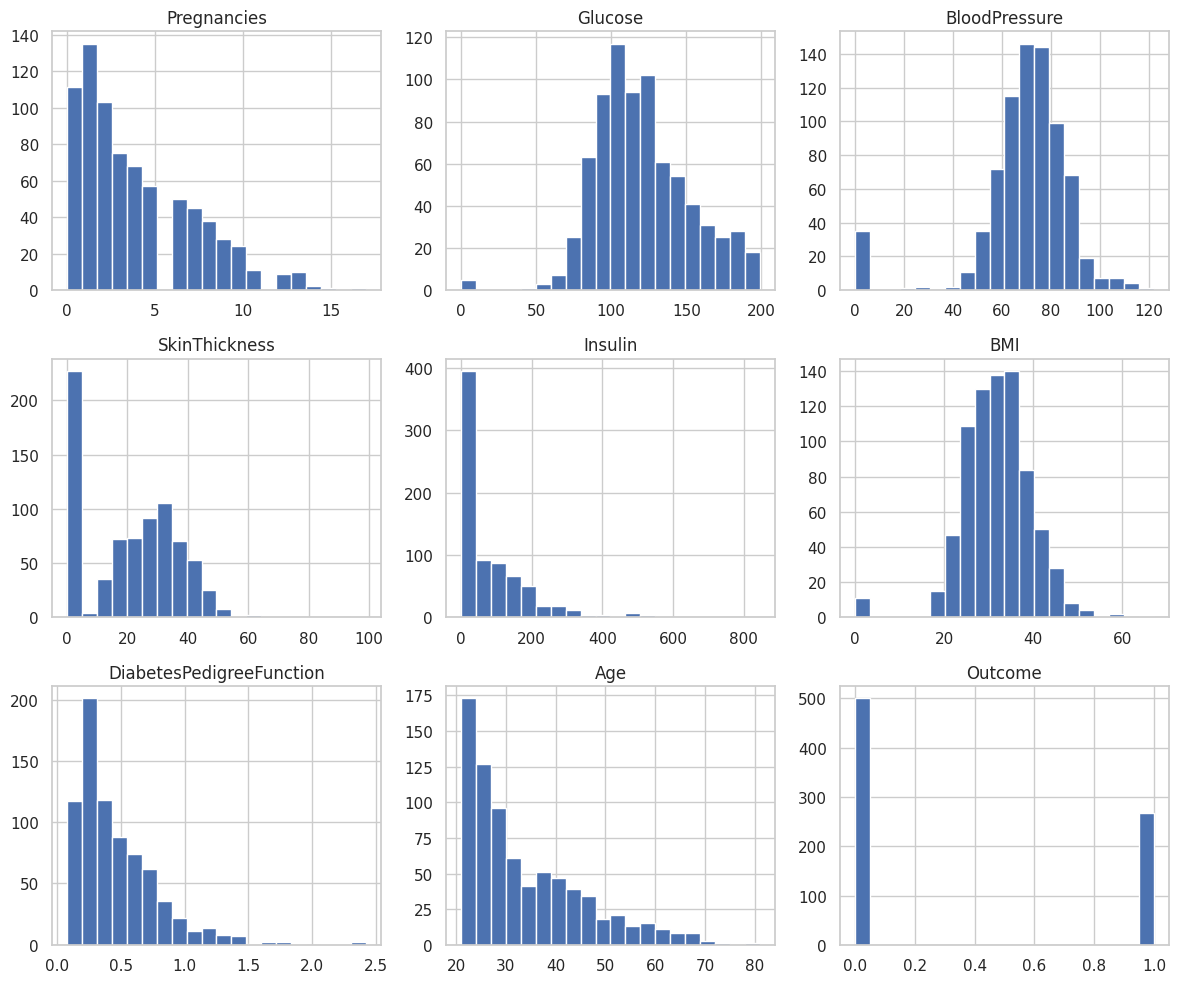

In [ ]:
# EDA(EXPLORATORY DATA ANALYSIS)
df.hist(bins=20, figsize=(12, 10))
plt.tight_layout()
plt.show()

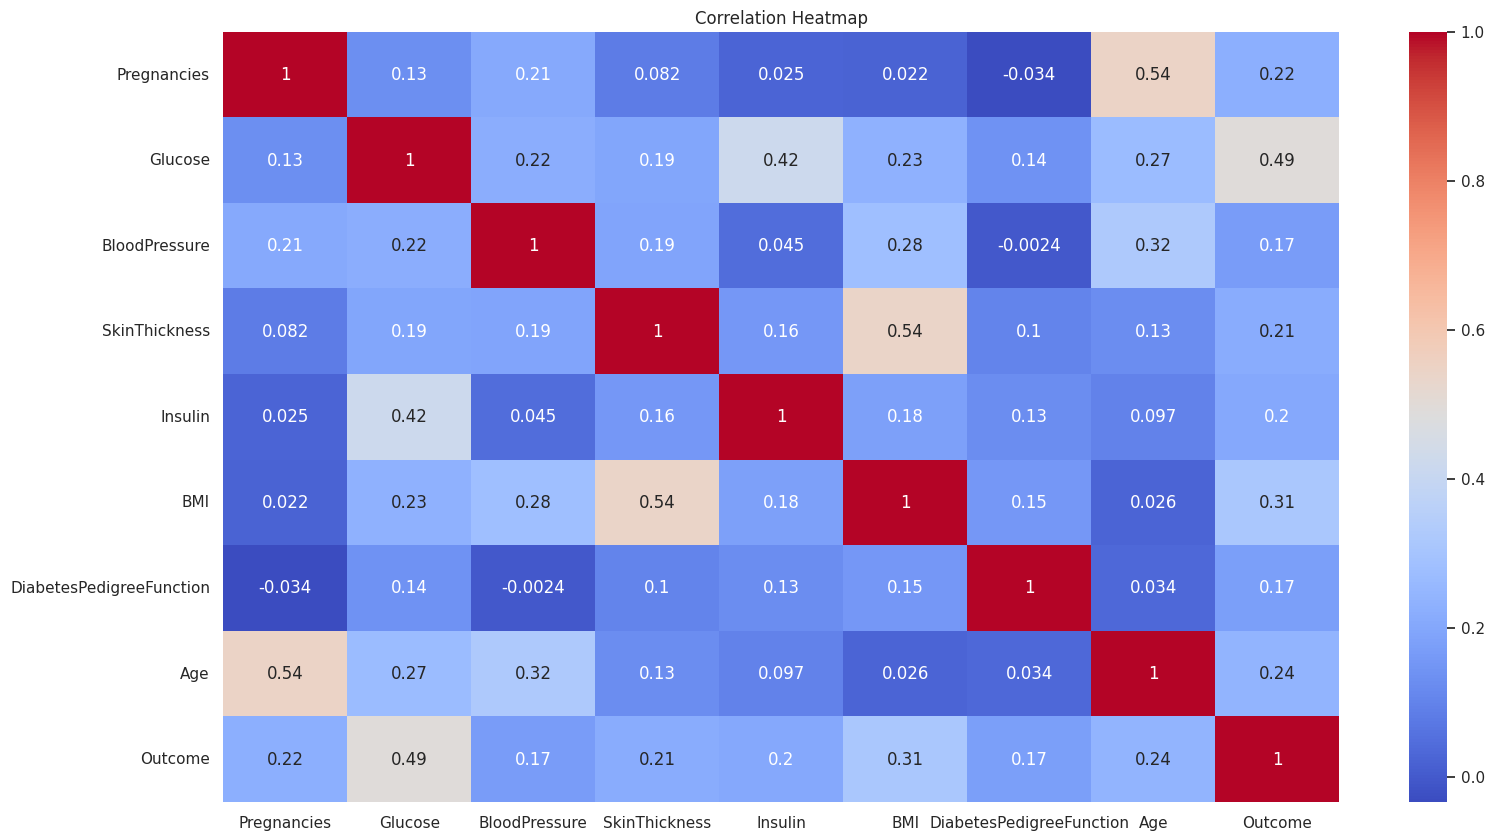

In [ ]:
plt.figure(figsize=(18, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#DATA CLEANING
cols_with_zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zero_as_missing:
  df[col] = df[col].replace(0, np.nan)
  df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
X = df.drop('Outcome', axis=1)
Y = df['Outcome']

print("Features shape:", X.shape)
print("Target shape:", Y.shape)

Features shape: (768, 8)
Target shape: (768,)


In [ ]:
# TRAIN/TEST SPLIT
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print("Train shape:", X_train.shape, Y_train.shape)
print("Test shape:", X_test.shape, Y_test.shape)

Train shape: (614, 8) (614,)
Test shape: (154, 8) (154,)


In [ ]:
# SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# MODEL TRAINING(LOGISTIC REGRESSION)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, Y_train)

Y_pred = log_reg.predict(X_test_scaled)

acc = accuracy_score(Y_test, Y_pred)
print("Accuracy:", acc)

print("Classification Report:")
print(classification_report(Y_test, Y_pred))

Accuracy: 0.7077922077922078
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



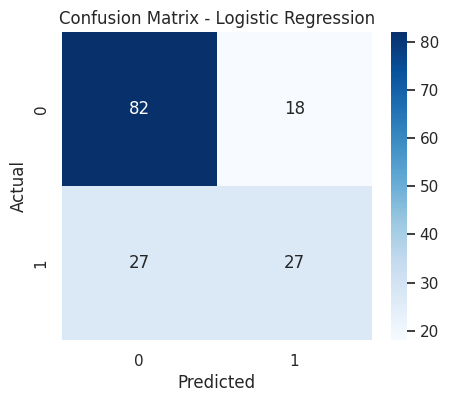

In [ ]:
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)

rf_clf.fit(X_train, Y_train)
Y_pred_rf = rf_clf.predict(X_test)
acc_rf = accuracy_score(Y_test, Y_pred_rf)
print("Random Forest Acuracy:", acc_rf)
print("classification_report(Random Fast):")
print(classification_report(Y_test, Y_pred_rf))

Random Forest Acuracy: 0.7402597402597403
classification_report(Random Fast):
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



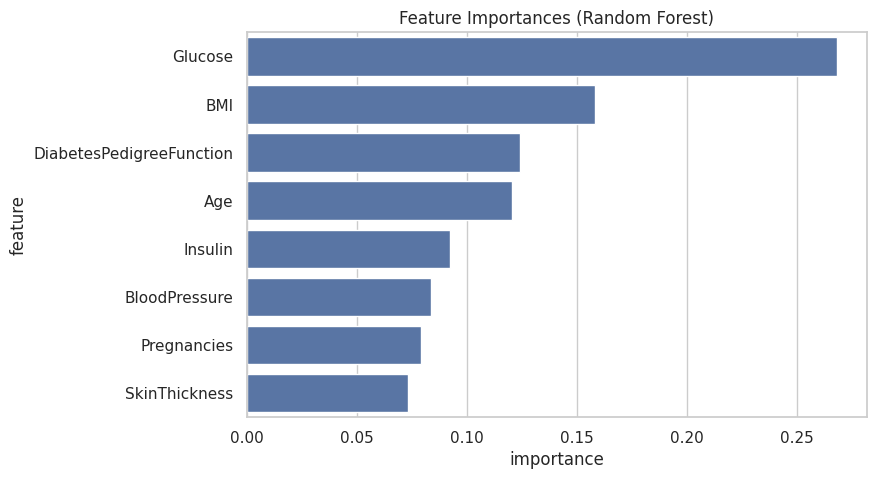

In [ ]:
importances = rf_clf.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=feat_imp_df)
plt.title("Feature Importances (Random Forest)")
plt.show()

In [ ]:
import joblib

joblib.dump(log_reg, 'logistic_regression_diabetes.pkl')
joblib.dump(scaler, 'scaler_diabetes.pkl')

print("Saved logistic_regression_diabetes.pkl and scaler_diabetes.pkl")

Saved logistic_regression_diabetes.pkl and scaler_diabetes.pkl


In [ ]:
def predict_diabetes(sample_list):
  """
  sample_list: list or array of 8 values in the same order as X columns.
  """
  sample_array = np.array(sample_list).reshape(1, -1)
  sample_scaled = scaler.transform(sample_array)
  pred = log_reg.predict(sample_scaled)[0]
  proba = log_reg.predict_proba(sample_scaled)[0][1]
  return pred, proba

example_patient = [2, 120, 70, 25, 80, 30.0, 0.5, 35]
pred_label, pred_proba = predict_diabetes(example_patient)
print("Predicted label (0 = no diabetes, 1 = diabetes):", pred_label)
print("Predicted probability of diabetes:", pred_proba)

Predicted label (0 = no diabetes, 1 = diabetes): 0
Predicted probability of diabetes: 0.21200837879106585


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
! pip install gradio

In [ ]:
import joblib

log_reg = joblib.load('logistic_regression_diabetes.pkl')
scaler = joblib.load('scaler_diabetes.pkl')

In [3]:
# PREDICTION FUNCTION FOR GRADIO

import numpy as np

def predict_diabetes_gradio(
    glucose,
    bmi,
    diabetes_pedigree,
    age,
    insulin,
    blood_pressure,
    pregnancies,
    skin_thickness,

):
    """
    Takes individual values and returns prediction and probability.
    These names must match the order of your original features.
    """
    # Pack into a 1-row array
    sample = np.array([
         glucose,
         bmi,
         diabetes_pedigree,
         age,
         insulin,
         blood_pressure,
         pregnancies,
         skin_thickness,
    ]).reshape(1, -1)

    # Scale the sample
    sample_scaled = scaler.transform(sample)

    # Predict
    pred = log_reg.predict(sample_scaled)[0]
    proba = log_reg.predict_proba(sample_scaled)[0][1]

    # Return human‑readable text
    risk = "HIGH" if pred == 1 else "LOW"
    return f"Predicted risk: {risk} (P(diabetes) ≈ {proba:.3f})"


import gradio as gr

#  interface
demo = gr.Interface(
    fn=predict_diabetes_gradio,
    inputs=[
        gr.Number(label="Glucose (mg/dL)"),
        gr.Number(label="BMI"),
        gr.Number(label="Diabetes Pedigree Function"),
        gr.Slider(10, 100, step=1, label="Age"),
        gr.Number(label="Insulin (mu U/ml)"),
        gr.Number(label="Blood Pressure (mm Hg)"),
        gr.Slider(0, 20, step=1, label="Pregnancies"),
        gr.Number(label="Skin Thickness (mm)"),
    ],
    outputs="text",
    title="DIABETES RISK PREDICTOR",
    description="Enter the patient's medical values and get a prediction.",
    examples=[
        [2, 120, 70, 25, 80, 30.0, 0.5, 35],
        [5, 180, 86, 30, 0, 32.0, 0.6, 45]
    ]
)

# Launch the Gradio app in Colab
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f2a41186fc541abf5d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
